<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [26]:
!pip install pandas
#import matplotlib.pyplot as plt
!pip install matplotlib
!pip install seaborn



### Step 1: Import Required Libraries


In [3]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [4]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
# Count how many rows are exact duplicates across all columns
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)
# Show the first few duplicate rows to understand their structure
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.head()



Number of duplicate rows: 10


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [7]:
## Write your code here
# Count how many rows are exact duplicates across all columns
num_duplicates_before = df.duplicated().sum()
print("Duplicate rows before removal:", num_duplicates_before)
# Remove full-row duplicates
df_cleaned = df.drop_duplicates()
# Count duplicates again after removal
num_duplicates_after = df_cleaned.duplicated().sum()
print("Duplicate rows after removal:", num_duplicates_after)


Duplicate rows before removal: 10
Duplicate rows after removal: 0


### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [13]:
## Write your code here
# Count missing values for each column
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

# Check missing values in EdLevel
print("Missing values in EdLevel:", df['EdLevel'].isnull().sum())
# Find the most frequent value
most_frequent_edlevel = df['EdLevel'].mode()[0]
print("Most frequent EdLevel value:", most_frequent_edlevel)

# Correct imputation (assign back to the DataFrame)
df['EdLevel'] = df['EdLevel'].fillna(most_frequent_edlevel)
print("Missing values in EdLevel after imputation:", df['EdLevel'].isnull().sum())





Missing values per column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64
Missing values in EdLevel: 4653
Most frequent EdLevel value: Bachelor’s degree (B.A., B.S., B.Eng., etc.)
Missing values in EdLevel after imputation: 0


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [17]:
## Write your code here
# Count missing values in ConvertedCompYearly
missing_comp = df['ConvertedCompYearly'].isnull().sum()
print("Missing values in ConvertedCompYearly:", missing_comp)
df['ConvertedCompYearly'].describe()
# No imputation; keep missing values
#Recommended approach: Do NOT impute with mean/mode
#Salary data is:highly skewed
#intentionally missing for many respondents
#not safe for simple imputation
#The safest approach is option1:Leave missing values as-is (preferred for analysis)
#df_comp = df.copy()
#option2:Drop rows with missing compensation (if analysis requires complete salary data)
# Drop rows where compensation is missing
df_comp = df.dropna(subset=['ConvertedCompYearly'])

print("Rows after dropping missing compensation:", df_comp.shape[0])


Missing values in ConvertedCompYearly: 42012
Rows after dropping missing compensation: 23435


### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


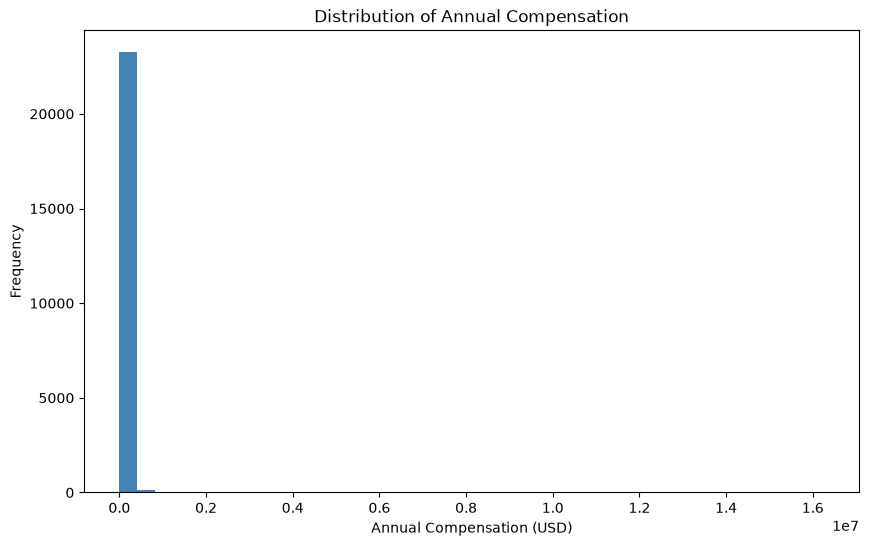

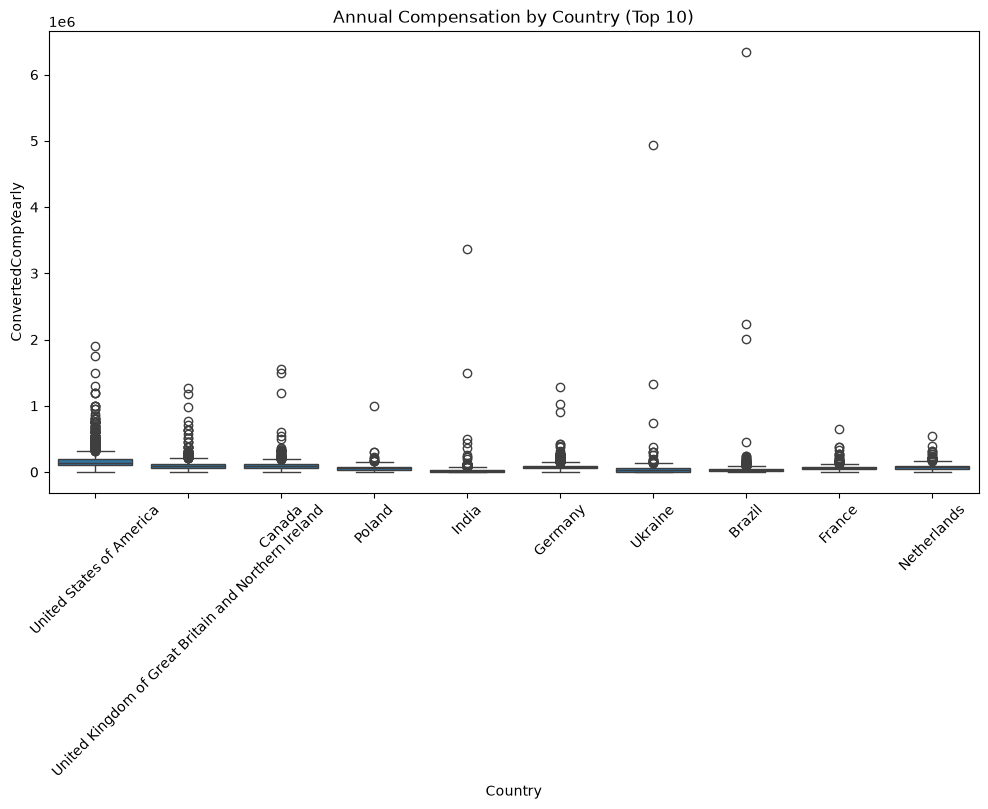

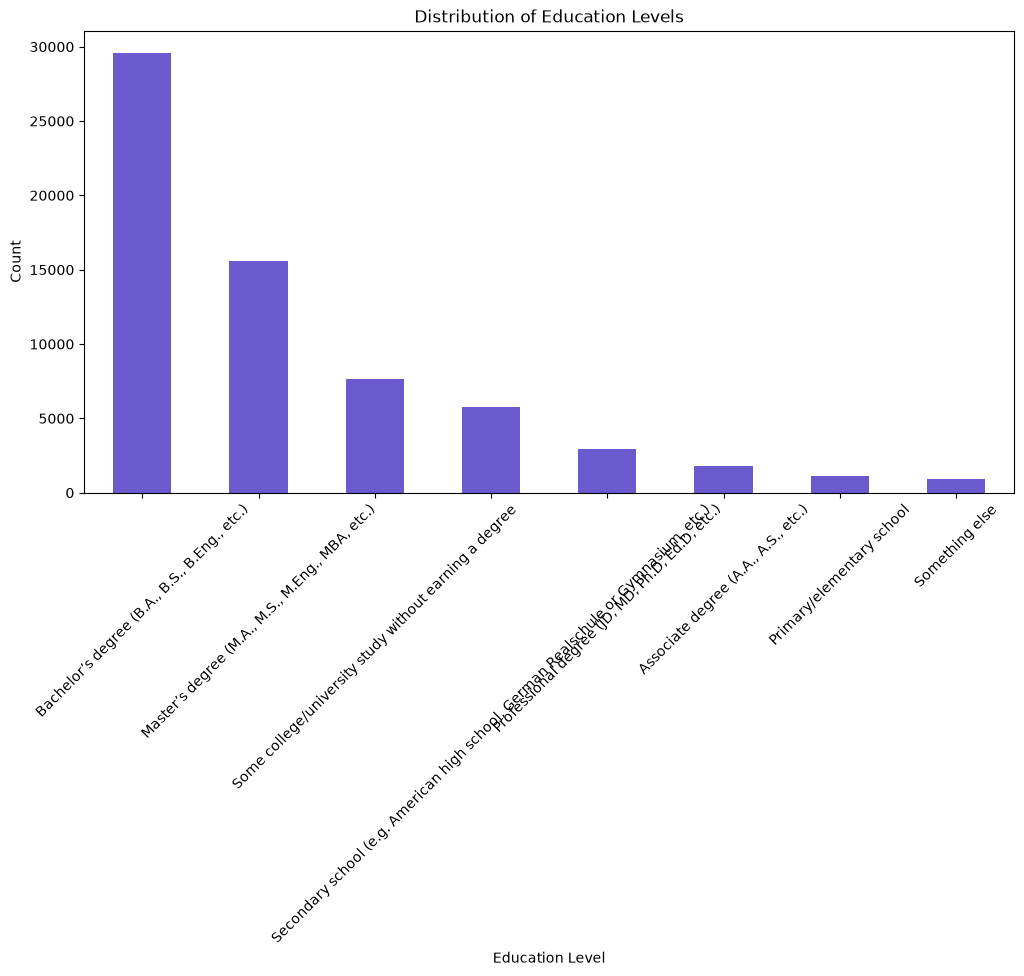

In [27]:
## Write your code here
# Summary statistics for numeric columns
#df.describe()
# Value counts for selected categorical columns
#print(df['Country'].value_counts().head(10))
#print(df['EdLevel'].value_counts().head(10))
#print(df['Employment'].value_counts().head(10))
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['ConvertedCompYearly'].dropna(), bins=40, color='steelblue')
plt.title('Distribution of Annual Compensation')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Frequency')
plt.show()

import seaborn as sns

# Select top 10 countries by respondent count
top_countries = df['Country'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Country'].isin(top_countries)],
            x='Country', y='ConvertedCompYearly')
plt.xticks(rotation=45)
plt.title('Annual Compensation by Country (Top 10)')
plt.show()

plt.figure(figsize=(12,6))
df['EdLevel'].value_counts().plot(kind='bar', color='slateblue')
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()



<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
